---
title: Math Puzzles
short_title: Dominoes on a Chessboard
subtitle: Dominoes on a Chessboard


numbering:
  headings: false

numbered_references: false
---

This chapter will help you get consolidate your knowledge of linear algebra. To solve the exercises in this section you will need to have some basic understanding of:

- numpy arrays
- loops and if statements
- recursion 
- functions

This quest was inspired by {cite}`singh1997fermat`.

# Problem:

A Chessboard consists of 64 squares, organized in a 8 by 8 grid. The squares have alternating colors (usually black and white), in such a way that a square never share edges with a square of the same color. 

:::{figure} https://upload.wikimedia.org/wikipedia/commons/thumb/d/d7/Chessboard480.svg/500px-Chessboard480.svg.png
:width: 300px
:align: center
A typical chessboard. Source: {cite}`Chessboard`
:::

Imagine that you have a modified Chessboard, in which the first and last squares of one of the diagonals were removed. This new board has now 62 squares. Is it possible to tile a this board with a set of 31 dominoes, so that each domino covers exactly two squares of the board and there are no squares uncovered?

Use your programming skills to find a viable tiling pattern for the board, or to prove that a pattern is not possible. 

::::{dropdown} Solution
Here is an implementation using recursion. The function `generate_boards` returns a list of all possible tiling configurations, or False if no configuration is possible.

Since there are a lot of possible configurations to test, it can take a while (~5min) to run the code below. Before diving into the actual response of the problem, you can "test" if the code is actually working properly by trying with a 4 by 4 matrix with no constraints (that's simple enough for us to know that a solution is possible). See the following section.

:::{code-cell}
:tags:[skip-execution]
import numpy as np 
import matplotlib.pyplot as plt

def step(i,j,s):
    j+=1
    if j>=s:
        j=0
        i+=1
    return i,j

def add_vertical(board,i,j,valid = True, valid_boards =[]):
    if not valid:
        return False

    # Check if it's possible to add a vertical tile
    if i+1==board.shape[0]:
        return False
    else:
        board[i,j]+=3
        board[i+1,j]+=3

    # Check for overlapping tiles 
    if board[i,j]%2==0 or board[i+1,j]%2==0:
        return False
    
    # Adjust i and j to the next position
    while board[i,j]!=0:
        i,j = step(i,j,board.shape[0])

        # Check if we are finished
        if i==board.shape[0]:
            valid_boards.append(board-2)
            return True

    # Try to add a new vertical/horizontal tile 
    valid1 = add_vertical(board.copy(), i, j, valid, valid_boards)
    valid2 = add_horizontal(board.copy(), i, j, valid, valid_boards)
    return valid1 or valid2    

def add_horizontal(board,i,j,valid = True, valid_boards=[]):
    if not valid:
        return False
    
    # Check if it's possible to add a horizontal tile
    if j+1==board.shape[0]:
        return False
    else:
        board[i,j]+=1
        board[i,j+1]+=1
    
        
    # Check for overlapping tiles 
    if board[i,j]%2==0 or board[i,j+1]%2==0:
        return False
        
    # Adjust i and j to the next position
    while board[i,j]!=0:
        i,j = step(i,j,board.shape[0])
            
        # Check if we are finished
        if i==board.shape[0]:
            valid_boards.append(board-2)
            return True

    # Try to add a new vertical/horizontal tile 
    valid1 = add_vertical(board.copy(), i, j, valid, valid_boards)
    valid2 = add_horizontal(board.copy(), i, j, valid, valid_boards)
    return valid1 or valid2

def generate_boards(board):
    valid_boards=[]
    i=0
    j=0
    # Adjust i and j to the next valid position
    while board[i,j]!=0:
        i,j = step(i,j,board.shape[0])
            
        # Check if we are finished
        if i==board.shape[0]:
            valid_boards.append(board-2)
    valid1 = add_vertical(board.copy(),i,j, True, valid_boards)
    valid2 = add_horizontal(board.copy(),i,j,True, valid_boards)
    if valid1 or valid2:
        return valid_boards
    else:
        return False 

# Testing with a 8 by 8 boards
i = 0
j = 0

# Initializing the board
board = np.zeros((8,8))

# Adding constraints
board[0][0] = 1
board[7][7] = 1

# Computing all possible combinations
valid_boards = generate_boards(board)
:::
::::

::::{dropdown} Testing solution with a 4-by-4 board
:::{code-cell} python
:tags: [skip-execution]
# Testing with a 4 by 4 boards
i = 0
j = 0

# Initializing the board
board = np.zeros((4,4))

# Computing all possible combinations
valid_boards = generate_boards(board)

# Plotting a set of possible solutions
fig = plt.figure()
for i in range(8):
    ax = plt.subplot(2,4,i+1)
    cax = ax.matshow(valid_boards[i],cmap = 'coolwarm')
    ax.set_xticks(np.arange(-0.5, 3.5, 1))
    ax.set_yticks(np.arange(-0.5, 3.5, 1))
    ax.grid(color='k', linestyle='-', linewidth=2)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    if i%4==3:
        cbar = plt.colorbar(cax, ticks=[-1, 1],fraction=0.046, pad=0.04)
        cbar.ax.set_yticklabels(['horizontal', 'vertical'])
plt.show()
:::

![](#4by4)

Our function seems to be working properly and finding possible solutions to the 4 by 4 board. However, if you run the code for the original problem, you will see that there is no tiling configuration possible with these constraints. Try it out! 

::::



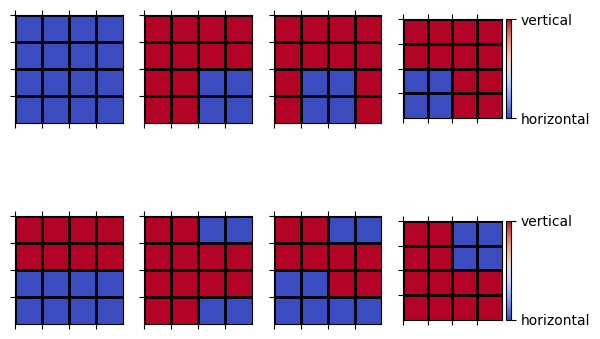

In [ ]:
#| label: 4by4
import numpy as np 
import matplotlib.pyplot as plt

def step(i,j,s):
    j+=1
    if j>=s:
        j=0
        i+=1
    return i,j

def add_vertical(board,i,j,valid = True, valid_boards =[]):
    if not valid:
        return False

    # Check if it's possible to add a vertical tile
    if i+1==board.shape[0]:
        return False
    else:
        board[i,j]+=3
        board[i+1,j]+=3

    # Check for overlapping tiles 
    if board[i,j]%2==0 or board[i+1,j]%2==0:
        return False
    
    # Adjust i and j to the next position
    while board[i,j]!=0:
        i,j = step(i,j,board.shape[0])

        # Check if we are finished
        if i==board.shape[0]:
            valid_boards.append(board-2)
            return True

    # Try to add a new vertical/horizontal tile 
    valid1 = add_vertical(board.copy(), i, j, valid, valid_boards)
    valid2 = add_horizontal(board.copy(), i, j, valid, valid_boards)
    return valid1 or valid2    

def add_horizontal(board,i,j,valid = True, valid_boards=[]):
    if not valid:
        return False
    
    # Check if it's possible to add a horizontal tile
    if j+1==board.shape[0]:
        return False
    else:
        board[i,j]+=1
        board[i,j+1]+=1
    
        
    # Check for overlapping tiles 
    if board[i,j]%2==0 or board[i,j+1]%2==0:
        return False
        
    # Adjust i and j to the next position
    while board[i,j]!=0:
        i,j = step(i,j,board.shape[0])
            
        # Check if we are finished
        if i==board.shape[0]:
            valid_boards.append(board-2)
            return True

    # Try to add a new vertical/horizontal tile 
    valid1 = add_vertical(board.copy(), i, j, valid, valid_boards)
    valid2 = add_horizontal(board.copy(), i, j, valid, valid_boards)
    return valid1 or valid2

def generate_boards(board):
    valid_boards=[]
    i=0
    j=0
    # Adjust i and j to the next valid position
    while board[i,j]!=0:
        i,j = step(i,j,board.shape[0])
            
        # Check if we are finished
        if i==board.shape[0]:
            valid_boards.append(board-2)
    valid1 = add_vertical(board.copy(),i,j, True, valid_boards)
    valid2 = add_horizontal(board.copy(),i,j,True, valid_boards)
    if valid1 or valid2:
        return valid_boards
    else:
        return False 

# Testing with a 4 by 4 boards
i = 0
j = 0

# Initializing the board
board = np.zeros((4,4))

# Computing all possible combinations
valid_boards = generate_boards(board)

# Plotting a set of possible solutions
fig = plt.figure()
for i in range(8):
    ax = plt.subplot(2,4,i+1)
    cax = ax.matshow(valid_boards[i],cmap = 'coolwarm')
    ax.set_xticks(np.arange(-0.5, 3.5, 1))
    ax.set_yticks(np.arange(-0.5, 3.5, 1))
    ax.grid(color='k', linestyle='-', linewidth=2)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    if i%4==3:
        cbar = plt.colorbar(cax, ticks=[-1, 1],fraction=0.046, pad=0.04)
        cbar.ax.set_yticklabels(['horizontal', 'vertical'])
plt.show()



::::{dropdown} The engineering way vs. the mathematical way

We proved that there is no possible tiling of the modified board by trying every possible combination. Something that it's only possible using a computer (we tested around 2^31 combinations!). One could say that this is an "engineering" way of approaching this problem. However, there is also a more "mathematical" way of reaching the same solution that involves no computation at all! Can you figure it out by yourself? 

:::{hint}
:class:dropdown
Is the color element of the board relevant for this problem?
:::

:::{dropdown} Mathematical solution
Think about the color pattern on the board. A domino piece must necessarily cover one black square and one white square, however, we removed two squares of the same color (since they are in the same diagonal). This means that there are 32 and 30 squares of the same color. The first 30 squares of both colors are possible to cover using dominoes. But the last two squares are of the same color, making it impossible to cover it with a domino.  

You can also test this in the 4-by-4 square. See what happens if you remove squares of the same or different colors! This is a very elegant way of solving the problem, without actually testing any tiling pattern. However, most problems do not have a similar simple solution like this one.

:::
::::